#  Exploratory Data Analysis (EDA)

##  Overview
This notebook focuses on exploring the cleaned insurance dataset to uncover patterns, relationships, and key drivers of insurance claims (`claim_status`). 

The goal is to move beyond data preparation and begin extracting meaningful insights that can inform predictive modeling and business decisions.

##  Objectives
- Understand the distribution of key features  
- Analyze relationships between variables and claim occurrence  
- Identify important predictors of insurance risk  
- Detect patterns, trends, and anomalies in the data  

### Importing the working libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Warnings control
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (8, 5)

print("✓ EDA libraries loaded successfully")

✓ EDA libraries loaded successfully


In [2]:
# Load cleaned dataset
df = pd.read_csv("cleaned_insurance_data.csv")

### Preliminary Data Overview

In [3]:
print("🔹 DATA PREVIEW:")
display(df.head())

print("\n" + "="*80)

print("🔹 SHAPE (rows, columns):")
print(df.shape)

print("\n" + "="*80)

print("🔹 DATA TYPES:")
print(df.dtypes)

print("\n" + "="*80)

print("🔹 MISSING VALUES:")
total_missing = df.isna().sum().sum()
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    display(df.isna().sum()[df.isna().sum() > 0])
else:
    print("✓ No missing values")

print("\n" + "="*80)

print("🔹 UNIQUE VALUES (selected columns):")
display(df.nunique().sort_values(ascending=False).head(10))

🔹 DATA PREVIEW:


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,1,1,1,1,1,0,1,1,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,0,1,1,1,1,1,1,1,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,1,1,1,1,1,0,1,1,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,0,0,0,1,0,0,0,1,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,0,1,1,1,0,0,1,1,5,0



🔹 SHAPE (rows, columns):
(58592, 41)

🔹 DATA TYPES:
policy_id                            object
subscription_length                 float64
vehicle_age                         float64
customer_age                          int64
region_code                          object
region_density                        int64
segment                              object
model                                object
fuel_type                            object
max_torque                           object
max_power                            object
engine_type                          object
airbags                               int64
is_esc                                int64
is_adjustable_steering                int64
is_tpms                               int64
is_parking_sensors                    int64
is_parking_camera                     int64
rear_brakes_type                     object
displacement                          int64
cylinder                              int64
transmission_type      

policy_id              58592
subscription_length      140
vehicle_age               49
customer_age              41
region_code               22
region_density            22
model                     11
engine_type               11
gross_weight              10
width                     10
dtype: int64

The dataset contains **58,592 records and 41 features**, confirming a large and well-structured insurance dataset. There are no missing values, indicating strong data completeness after cleaning. The data includes a mix of numeric, categorical, and binary features, with proper type assignments across all columns. Several variables such as `policy_id` show high uniqueness, confirming they are identifiers rather than predictive features. Overall, the dataset is clean, consistent, and ready for exploratory analysis and modeling.


### Target Variable Distribution (claim_status)

In [4]:
# Distribution
claim_counts = df['claim_status'].value_counts()
claim_pct = df['claim_status'].value_counts(normalize=True) * 100

no_claim = claim_counts[0]
claim = claim_counts[1]
claim_rate = claim_pct[1]

print(f"\n CLASS DISTRIBUTION:")
print(f"   🟢 No Claim (0): {no_claim:,} ({100-claim_rate:.2f}%)")
print(f"   🔴 Claim (1):    {claim:,} ({claim_rate:.2f}%)")

print(f"\n Imbalance Ratio: {no_claim/claim:.1f}:1")


 CLASS DISTRIBUTION:
   🟢 No Claim (0): 54,844 (93.60%)
   🔴 Claim (1):    3,748 (6.40%)

 Imbalance Ratio: 14.6:1


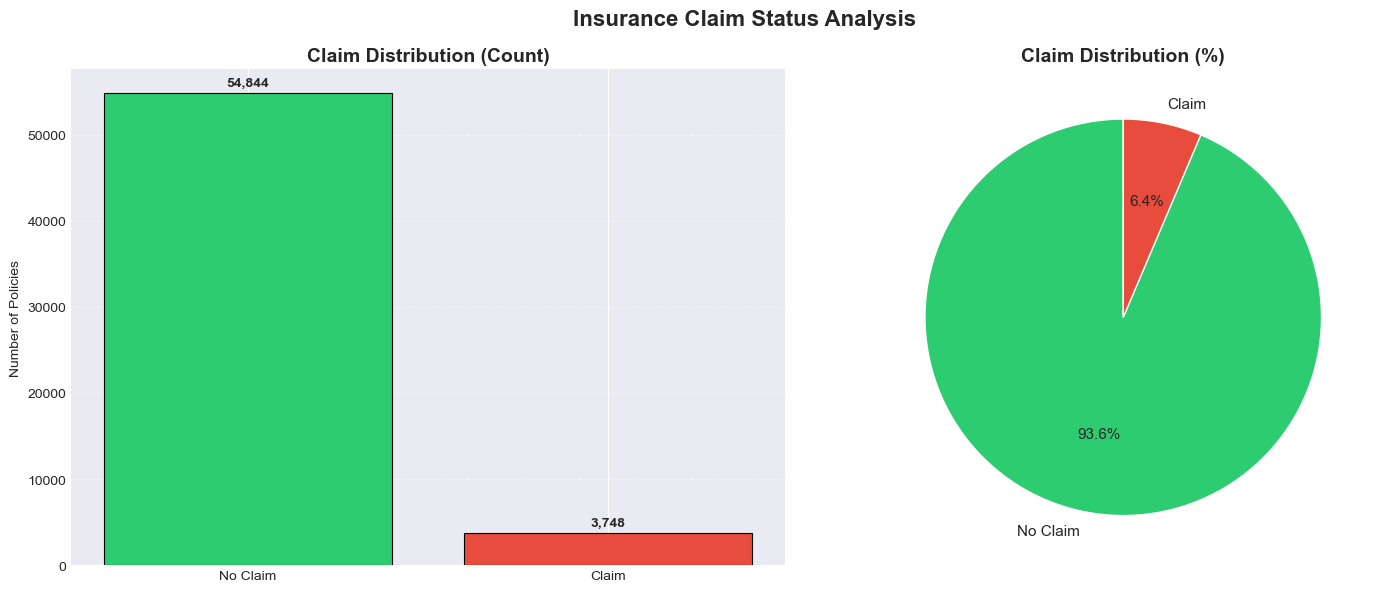

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#2ecc71', '#e74c3c']

# ---------------- Bar Chart ----------------
bars = axes[0].bar(
    ['No Claim', 'Claim'],
    claim_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

axes[0].set_title("Claim Distribution (Count)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Number of Policies")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Value labels
for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height + 800,
        f'{height:,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# ---------------- Pie Chart ----------------
axes[1].pie(
    claim_counts.values,
    labels=['No Claim', 'Claim'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

axes[1].set_title("Claim Distribution (%)", fontsize=14, fontweight='bold')

# Overall title
plt.suptitle("Insurance Claim Status Analysis", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Numeric Distribution Plots


📊 Numerical features: 12


,mean,std,min,max,skewness
subscription_length,6.11,4.14,0.0,14.0,0.05
vehicle_age,1.39,1.13,0.0,20.0,1.09
customer_age,44.82,6.94,35.0,75.0,0.66
region_density,18826.86,17660.17,290.0,73430.0,1.67
airbags,3.14,1.83,1.0,6.0,0.91
displacement,1162.36,266.30,796.0,1498.0,-0.11
cylinder,3.63,0.48,3.0,4.0,-0.53
turning_radius,4.85,0.23,4.5,5.2,0.42
length,3850.48,311.46,3445.0,4300.0,0.15
width,1672.23,112.09,1475.0,1811.0,-0.49


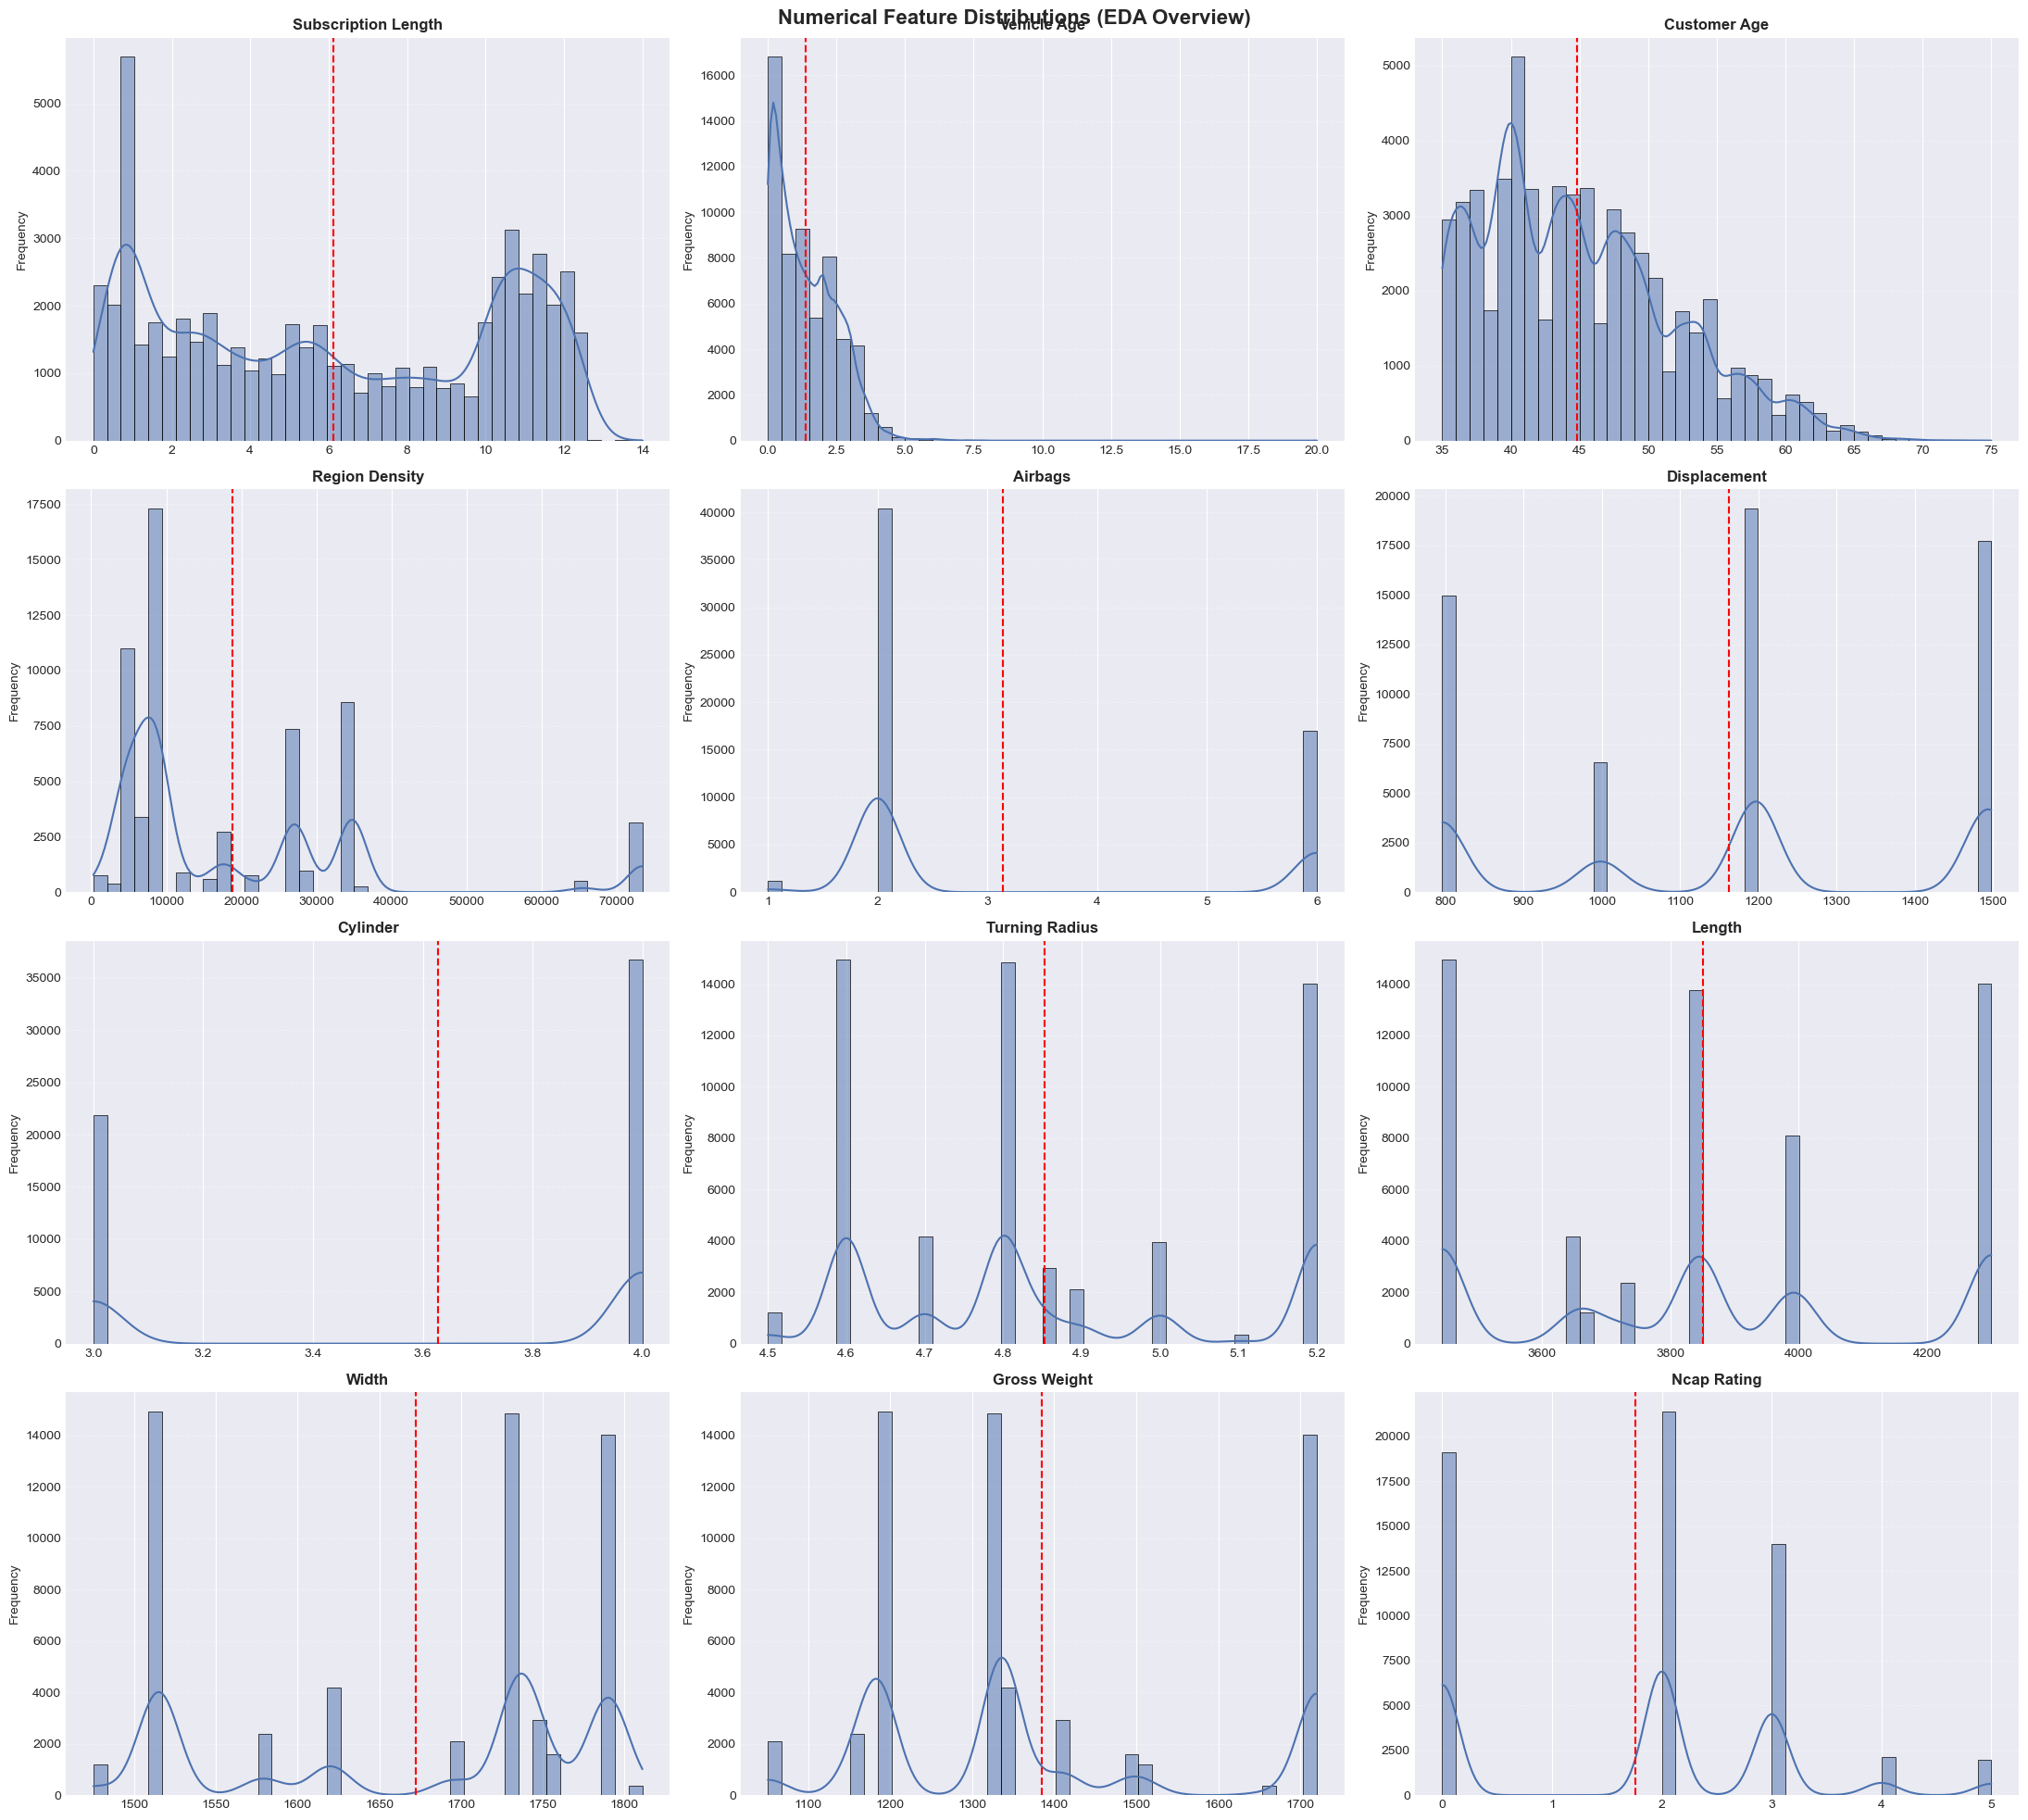

In [6]:
import math

# =============================================================================
# 1. FEATURE SELECTION
# =============================================================================

# Binary detection (safe)
binary_cols = [col for col in df.columns if set(df[col].dropna().unique()) <= {0, 1}]

# Numerical features excluding target + binary
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in binary_cols and col != 'claim_status']

print(f"\n📊 Numerical features: {len(numerical_cols)}")

# =============================================================================
# 2. STATISTICAL SUMMARY
# =============================================================================

stats_df = df[numerical_cols].describe().T
stats_df['missing'] = df[numerical_cols].isnull().sum()
stats_df['skewness'] = df[numerical_cols].skew()
stats_df['kurtosis'] = df[numerical_cols].kurtosis()

display(stats_df[['mean', 'std', 'min', 'max', 'skewness']].round(2))

# =============================================================================
# 3. DISTRIBUTION VISUALIZATION (HYBRID STYLE)
# =============================================================================

cols = 3
rows = math.ceil(len(numerical_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(22, 5 * rows))
axes = axes.flatten()

color = "#4C72B0"

for i, col in enumerate(numerical_cols):

    sns.histplot(
        df[col].dropna(),
        bins=40,
        kde=True,
        ax=axes[i],
        color=color,
        edgecolor="black",
        linewidth=0.5
    )

    mean_val = df[col].mean()

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5)

    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numerical Feature Distributions (EDA Overview)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

The numerical features show a mix of well-behaved and moderately skewed distributions across the dataset. Most vehicle specifications such as engine displacement, dimensions, and cylinder count exhibit low variability, indicating standardized vehicle designs. Features like vehicle age and region density show noticeable positive skewness, suggesting the presence of outliers or uneven distribution across customers. Safety-related attributes such as airbags and NCAP ratings have limited ranges but meaningful variation for risk analysis. Overall, the dataset contains a balanced set of numerical features with a few key variables that may strongly influence claim behavior.


### Binary feature distribution

In [7]:
binary_cols = [col for col in df.columns if set(df[col].dropna().unique()) <= {0, 1}]

binary_summary = pd.DataFrame({
    'feature': binary_cols,
    '1_count': [df[col].sum() for col in binary_cols],
    '0_count': [len(df) - df[col].sum() for col in binary_cols],
    '1_%': [(df[col].mean() * 100) for col in binary_cols]
}).sort_values(by='1_%', ascending=False)

binary_summary

,feature,1_count,0_count,1_%
16,is_speed_alert,58229,363,99.380461
12,is_power_steering,57383,1209,97.936578
3,is_parking_sensors,56219,2373,95.949959
15,is_ecw,42435,16157,72.424563
10,is_power_door_locks,42435,16157,72.424563
11,is_central_locking,42435,16157,72.424563
1,is_adjustable_steering,35526,23066,60.632851
13,is_driver_seat_height_adjustable,34291,24301,58.525055
5,is_front_fog_lights,33928,24664,57.905516
9,is_brake_assist,32177,26415,54.917054


In [8]:
impact = []

for col in binary_cols:
    if col != 'claim_status':
        claim_rate_when_1 = df[df[col] == 1]['claim_status'].mean()
        claim_rate_when_0 = df[df[col] == 0]['claim_status'].mean()

        impact.append({
            'feature': col,
            'claim_rate_if_1': claim_rate_when_1,
            'claim_rate_if_0': claim_rate_when_0,
            'impact_diff': claim_rate_when_1 - claim_rate_when_0
        })

impact_df = pd.DataFrame(impact).sort_values(by='impact_diff', ascending=False)

impact_df

,feature,claim_rate_if_1,claim_rate_if_0,impact_diff
16,is_speed_alert,0.064109,0.041322,0.022787
3,is_parking_sensors,0.064391,0.053940,0.010451
1,is_adjustable_steering,0.066712,0.059742,0.006970
5,is_front_fog_lights,0.066435,0.060574,0.005861
9,is_brake_assist,0.066383,0.061026,0.005357
13,is_driver_seat_height_adjustable,0.066169,0.060862,0.005307
14,is_day_night_rear_view_mirror,0.066463,0.062436,0.004027
12,is_power_steering,0.064043,0.060380,0.003663
11,is_central_locking,0.064970,0.061336,0.003634
15,is_ecw,0.064970,0.061336,0.003634


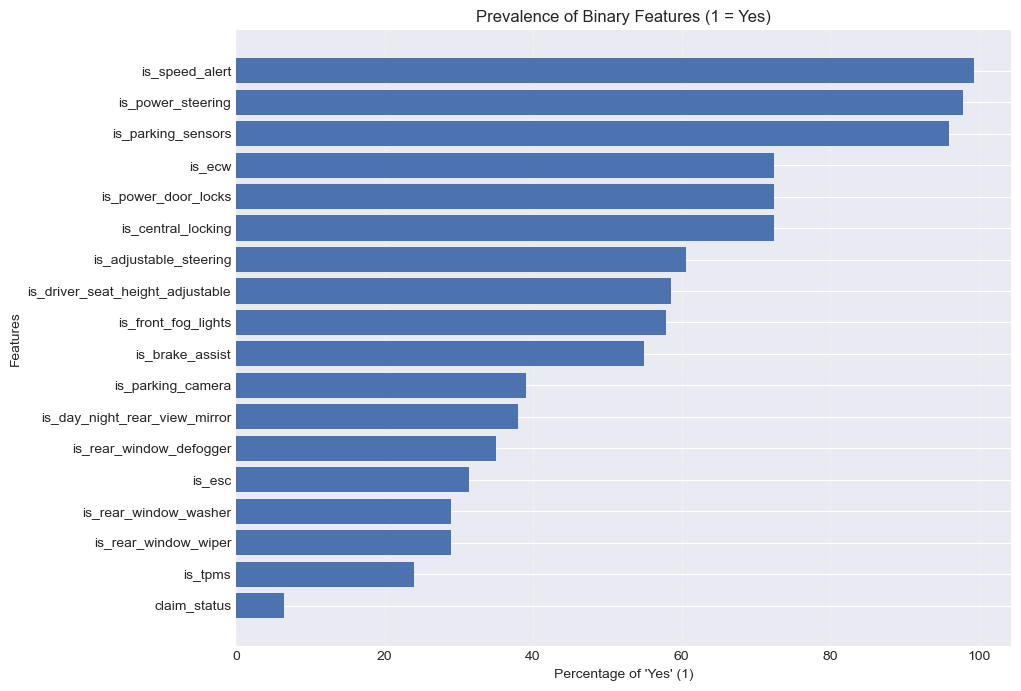

In [9]:
plt.figure(figsize=(10, 8))

binary_summary_sorted = binary_summary.sort_values('1_%')

plt.barh(binary_summary_sorted['feature'], binary_summary_sorted['1_%'], color="#4C72B0")

plt.title("Prevalence of Binary Features (1 = Yes)")
plt.xlabel("Percentage of 'Yes' (1)")
plt.ylabel("Features")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

The binary features show a strong imbalance in the distribution of vehicle safety and convenience systems across the dataset. Features such as speed alert, power steering, and parking sensors are almost universally present, indicating they are standard in most vehicles. In contrast, advanced safety and comfort features like ESC, TPMS, and rear window systems are less commonly installed, showing variation in vehicle safety levels. A noticeable mid-range group of features (e.g., brake assist, fog lights, seat adjustments) shows mixed adoption across vehicles. Overall, this pattern reflects a clear stratification between basic, standard, and advanced vehicle safety features in the dataset.

The results show that most binary safety and convenience features have only a small effect on claim probability. Features like speed alert and parking sensors show the highest positive impact, but the increase in claim rate is still relatively small. Many other features, such as ESC, TPMS, and parking camera, show almost no meaningful difference between presence and absence. The impact values are generally close to zero, indicating weak standalone predictive power for claims. Overall, these features provide limited individual influence on insurance risk.



### CATEGORICAL FEATURES ANALYSIS


 Found 11 categorical features


,feature,unique_values
0,policy_id,58592
1,region_code,22
3,model,11
7,engine_type,11
5,max_torque,9
6,max_power,9
2,segment,6
4,fuel_type,3
10,steering_type,3
8,rear_brakes_type,2



 Overall Claim Rate: 6.40%


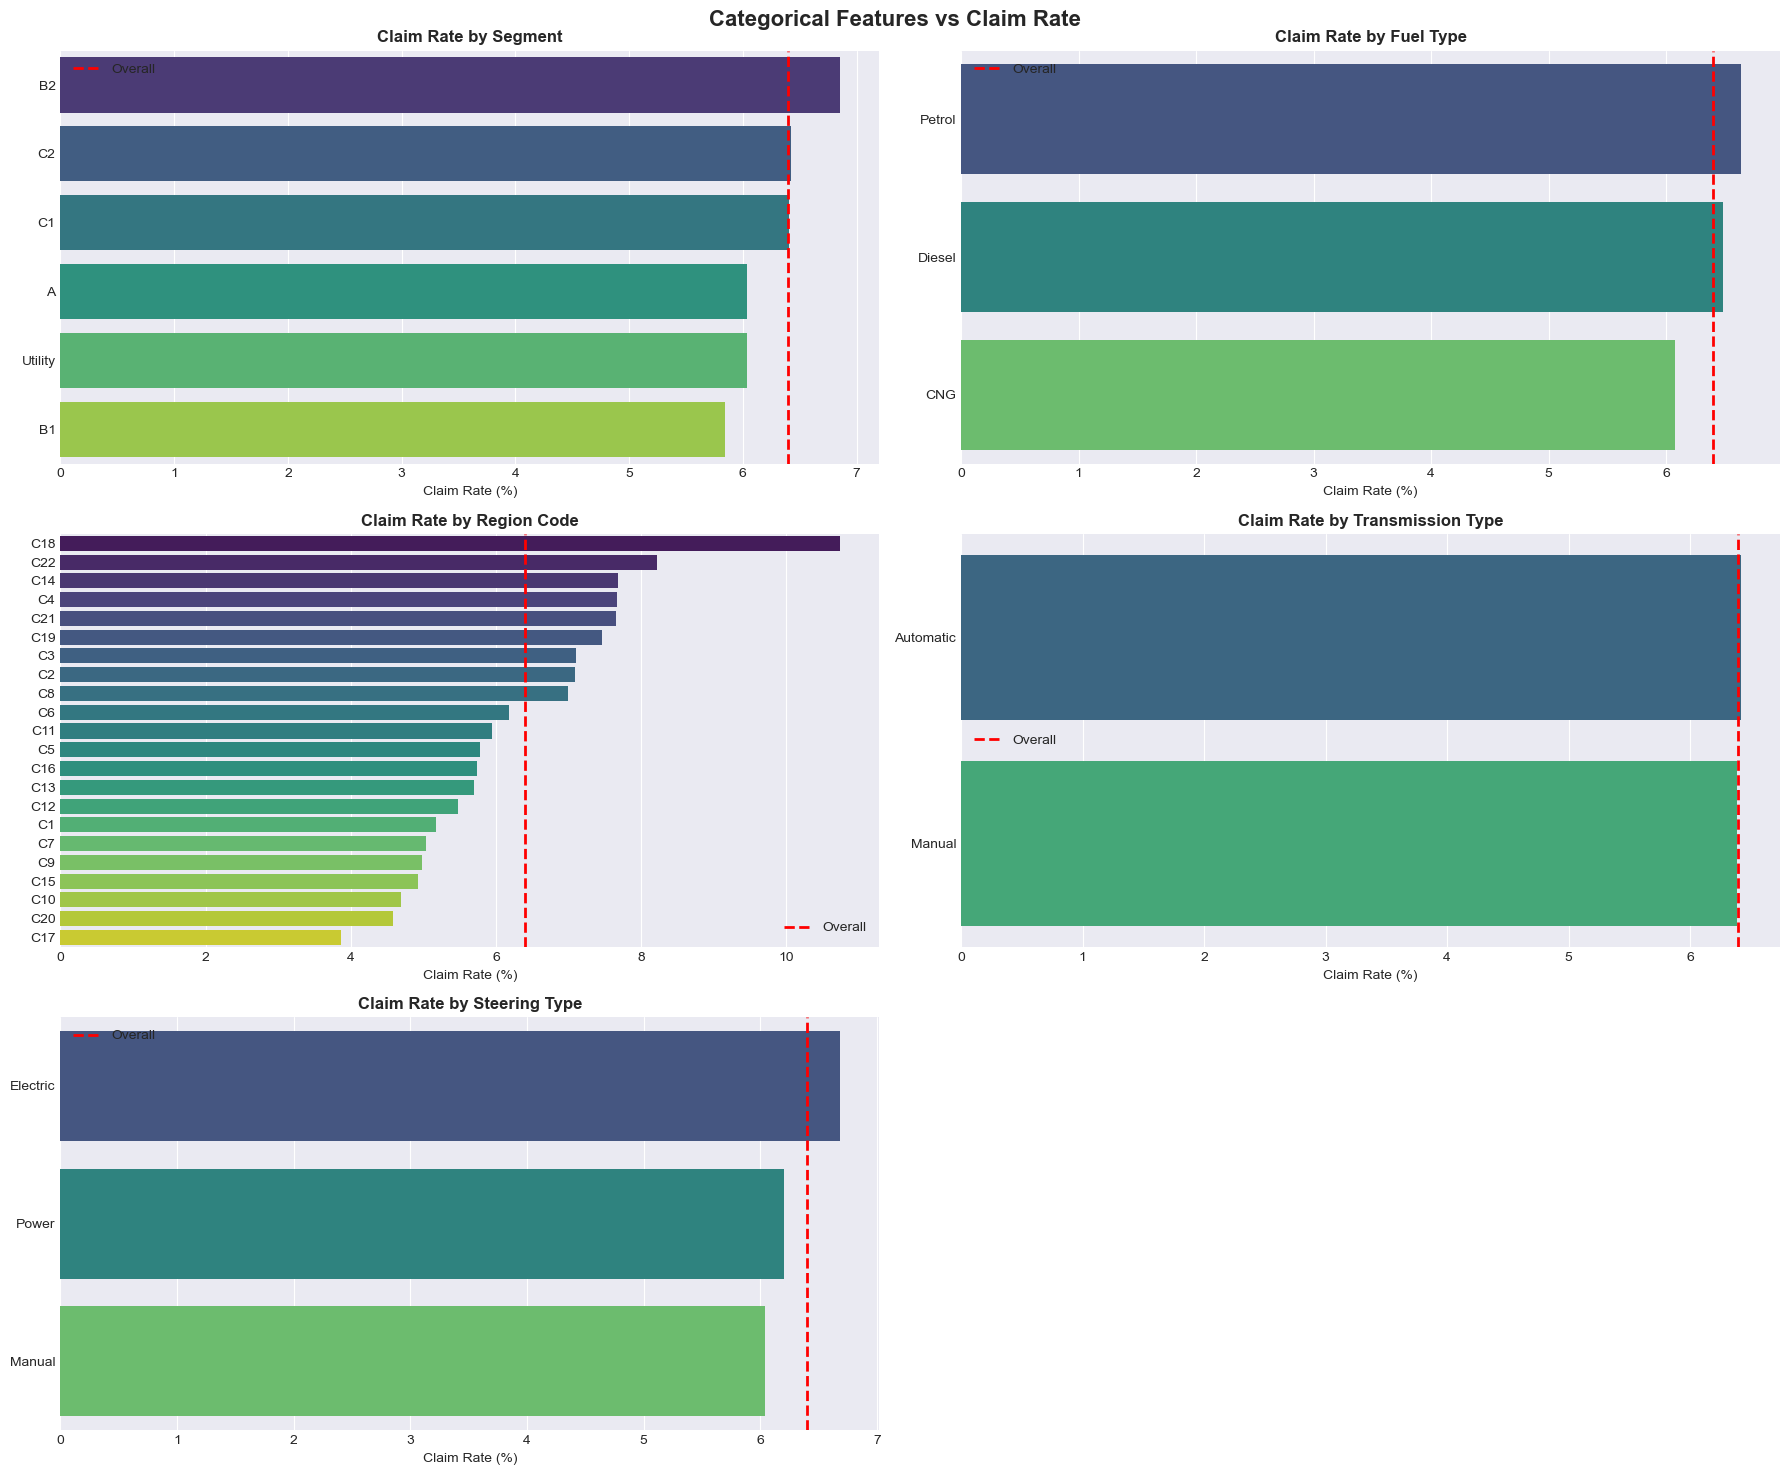


 Top Risk Categories per Feature


--- SEGMENT ---


,count,claim_rate
segment,,
B2,18314,0.068581
C2,14018,0.064275
C1,3557,0.064099
A,17321,0.060389
Utility,1209,0.060380



--- FUEL_TYPE ---


,count,claim_rate
fuel_type,,
Petrol,20532,0.066384
Diesel,17730,0.064862
CNG,20330,0.060748



--- REGION_CODE ---


,count,claim_rate
region_code,,
C18,242,0.107438
C22,207,0.082126
C14,3660,0.076776
C4,665,0.076692
C21,379,0.076517



--- TRANSMISSION_TYPE ---


,count,claim_rate
transmission_type,,
Automatic,20411,0.064181
Manual,38181,0.063854



--- STEERING_TYPE ---


,count,claim_rate
steering_type,,
Electric,23881,0.066873
Power,33502,0.062026
Manual,1209,0.060380


In [10]:
# -------------------------------
# 1. Identify categorical features
# -------------------------------
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n Found {len(categorical_cols)} categorical features")

# -------------------------------
# 2. Cardinality overview
# -------------------------------
cardinality_df = pd.DataFrame({
    "feature": categorical_cols,
    "unique_values": [df[col].nunique() for col in categorical_cols]
}).sort_values("unique_values", ascending=False)

display(cardinality_df)

# -------------------------------
# 3. Overall claim rate (baseline)
# -------------------------------
overall_claim_rate = df['claim_status'].mean()

print(f"\n Overall Claim Rate: {overall_claim_rate:.2%}")

# -------------------------------
# -------------------------------
key_categoricals = [
    col for col in ['segment', 'fuel_type', 'region_code',
                    'transmission_type', 'steering_type']
    if col in df.columns
]

# -------------------------------
# 5. Create dynamic plots
# -------------------------------
n = len(key_categoricals)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(key_categoricals):

    # compute claim rate per category
    temp = df.groupby(col)['claim_status'].mean().sort_values(ascending=False)

    sns.barplot(
        x=temp.values * 100,
        y=temp.index,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].axvline(overall_claim_rate * 100,
                    color='red',
                    linestyle='--',
                    linewidth=2,
                    label='Overall')

    axes[i].set_title(f"Claim Rate by {col.replace('_', ' ').title()}",
                      fontweight='bold')

    axes[i].set_xlabel("Claim Rate (%)")
    axes[i].set_ylabel("")

    axes[i].legend()

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical Features vs Claim Rate", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------
# 6. Deep dive table (top categories only)
# -------------------------------
print("\n Top Risk Categories per Feature\n")

for col in key_categoricals:
    print(f"\n--- {col.upper()} ---")

    summary = (
        df.groupby(col)['claim_status']
        .agg(['count', 'mean'])
        .rename(columns={'mean': 'claim_rate'})
        .sort_values('claim_rate', ascending=False)
    )

    display(summary.head(5))

The dataset contains 11 categorical features with varying levels of granularity, ranging from highly granular identifiers like policy_id to low-cardinality features such as transmission and steering type. The overall claim rate is 6.40%, providing a baseline for comparison across categories. Segment and fuel type show slight variations in claim rates, with B2 segment and petrol vehicles exhibiting marginally higher risk. Region code demonstrates the strongest differentiation, where certain regions show significantly elevated claim rates compared to the overall average. Overall, categorical features reveal mild but meaningful segmentation effects, with geography appearing as the most influential factor on claim behavior.

### FEATURE RELATIONSHIPS WITH CLAIMS


 Numerical Features vs Claims (Mean Comparison)



,feature,no_claim_mean,claim_mean,difference,p_value
0,subscription_length,6.026415,7.359472,1.333057,8.676762e-87
1,vehicle_age,1.396827,1.266222,-0.130605,4.735714e-13
2,customer_age,44.783623,45.413821,0.630198,1.611789e-07
3,region_density,18909.073445,17623.820438,-1285.253007,2.844770e-06
6,cylinder,3.625264,3.651814,0.026550,9.847117e-04
9,width,1671.942200,1676.498666,4.556466,1.495229e-02
5,displacement,1161.821348,1170.177161,8.355813,6.100240e-02
8,length,3849.948107,3858.214514,8.266407,1.130382e-01
10,gross_weight,1385.060554,1388.441302,3.380748,3.419417e-01
11,ncap_rating,1.758570,1.780149,0.021580,3.565869e-01



 Correlation with Claim Status (Top Drivers)



subscription_length    0.078738
customer_age           0.022234
cylinder               0.013434
width                  0.009947
displacement           0.007678
length                 0.006495
gross_weight           0.003894
ncap_rating            0.003800
airbags                0.002789
turning_radius         0.002724
Name: claim_status, dtype: float64

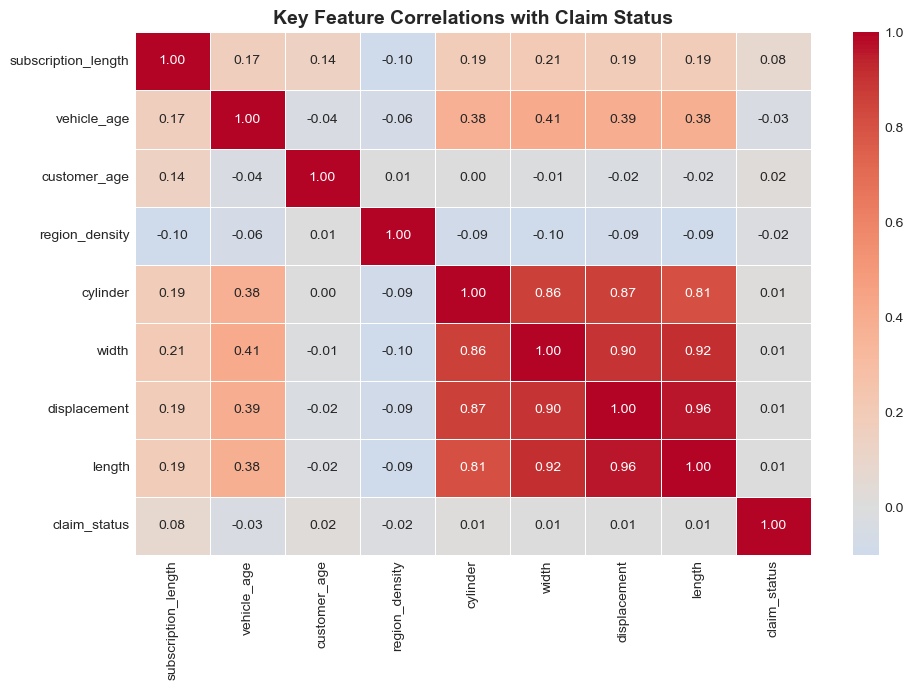

In [11]:

# -------------------------------
# 1. Split dataset once (OPTIMIZED)
# -------------------------------
df_no_claim = df[df['claim_status'] == 0]
df_claim = df[df['claim_status'] == 1]

# -------------------------------
# 2. Numerical comparison table
# -------------------------------
print("\n Numerical Features vs Claims (Mean Comparison)\n")

results = []

for col in numerical_cols:

    no_claim_mean = df_no_claim[col].mean()
    claim_mean = df_claim[col].mean()

    # statistical test (robust version)
    t_stat, p_value = stats.ttest_ind(
        df_no_claim[col],
        df_claim[col],
        equal_var=False
    )

    results.append([
        col,
        no_claim_mean,
        claim_mean,
        claim_mean - no_claim_mean,
        p_value
    ])

results_df = pd.DataFrame(results, columns=[
    "feature", "no_claim_mean", "claim_mean", "difference", "p_value"
])

results_df = results_df.sort_values("p_value")

display(results_df.head(10))

# -------------------------------
# 3. Correlation with target
# -------------------------------
print("\n Correlation with Claim Status (Top Drivers)\n")

correlations = (
    df[numerical_cols + ['claim_status']]
    .corr()['claim_status']
    .drop('claim_status')
    .sort_values(ascending=False)
)

display(correlations.head(10))

# -------------------------------
# 4. Clean correlation heatmap (important features only)
# -------------------------------
top_features = correlations.abs().sort_values(ascending=False).head(8).index.tolist()
top_features.append('claim_status')

corr_matrix = df[top_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Key Feature Correlations with Claim Status",
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The results show that subscription length has the strongest positive difference between claim and non-claim customers, indicating that longer policy duration is associated with higher claim likelihood. Vehicle age shows a slight negative relationship, suggesting newer vehicles may have marginally higher claims. Most other numerical features exhibit very small differences between the two groups, even when statistically significant. Correlation results confirm that no single numerical feature has strong predictive power on its own, with all correlations remaining relatively low. Overall, claims are influenced by multiple weak signals rather than any dominant numerical driver.

### SAFETY FEATURES ANALYSIS

,feature,rate_if_1_or_level,rate_if_0,impact
2,is_parking_sensors,0.064391,0.053940,0.010451
1,is_brake_assist,0.066383,0.061026,0.005357
0,is_esc,0.065051,0.063472,0.001579
4,is_tpms,0.064275,0.063871,0.000403
3,is_parking_camera,0.063702,0.064138,-0.000437


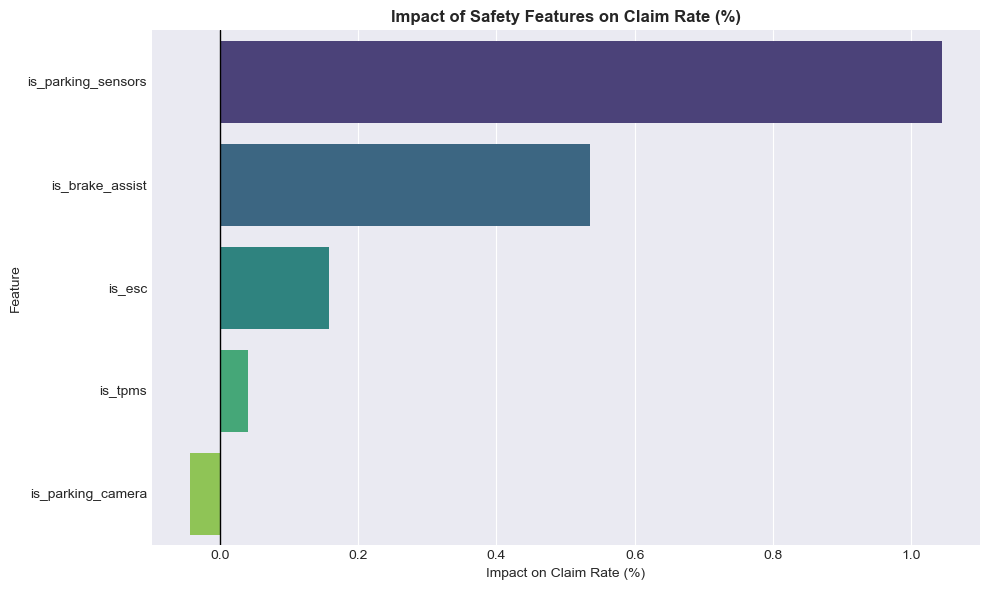

In [12]:
# -------------------------------
# 1. Define safety features
# -------------------------------
safety_features = [
    'is_esc', 'is_brake_assist', 'is_parking_sensors',
    'is_parking_camera', 'is_tpms', 'airbags', 'ncap_rating'
]

safety_features = [col for col in safety_features if col in df.columns]

# -------------------------------
# 2. Compute impact table (UNIFIED APPROACH)
# -------------------------------
safety_results = []

for feature in safety_features:

    if df[feature].nunique() <= 2:
        # binary features
        rate_1 = df[df[feature] == 1]['claim_status'].mean()
        rate_0 = df[df[feature] == 0]['claim_status'].mean()
        diff = rate_1 - rate_0

        safety_results.append([
            feature, rate_1, rate_0, diff
        ])

    else:
        # ordinal features (airbags, ncap_rating)
        grouped = df.groupby(feature)['claim_status'].mean()

        for val, rate in grouped.items():
            safety_results.append([
                f"{feature}={val}", rate, None, None
            ])

safety_df = pd.DataFrame(
    safety_results,
    columns=["feature", "rate_if_1_or_level", "rate_if_0", "impact"]
)

# -------------------------------
# 3. Display ranked impact (binary only)
# -------------------------------
binary_safety = safety_df.dropna().sort_values(
    by="impact", ascending=False
)

display(binary_safety)

# -------------------------------
# 4. Visualization
# -------------------------------
plt.figure(figsize=(10, 6))

plot_data = binary_safety.copy()
plot_data["impact_pct"] = plot_data["impact"] * 100

sns.barplot(
    data=plot_data,
    y="feature",
    x="impact_pct",
    palette="viridis"
)

plt.axvline(0, color='black', linewidth=1)
plt.title("Impact of Safety Features on Claim Rate (%)",
          fontweight='bold')
plt.xlabel("Impact on Claim Rate (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The results show that safety features have a very small overall impact on claim rates. Parking sensors exhibit the highest positive difference, suggesting a slight increase in claim probability when present, though the effect is still modest. Brake assist and ESC show minimal positive influence, indicating weak variation between users with and without these features. TPMS and parking camera have almost no meaningful impact, with values very close to zero. Overall, safety features do not strongly differentiate claim risk in this dataset.


### AGE ANALYSIS


 Customer Age
   Range  : 35 - 75
   Mean   : 44.82
   Median : 44.00

 Vehicle Age
   Range  : 0.0 - 20.0
   Mean   : 1.39
   Median : 1.20


,customer_age_claim_rate,vehicle_age_claim_rate
0-3 yrs,NaN,6.120362
18-25,NaN,NaN
26-35,5.900305,NaN
36-45,6.121168,NaN
4-7 yrs,NaN,4.462061
46-55,6.630872,NaN
56+,7.541302,NaN
8+ yrs,NaN,0.000000


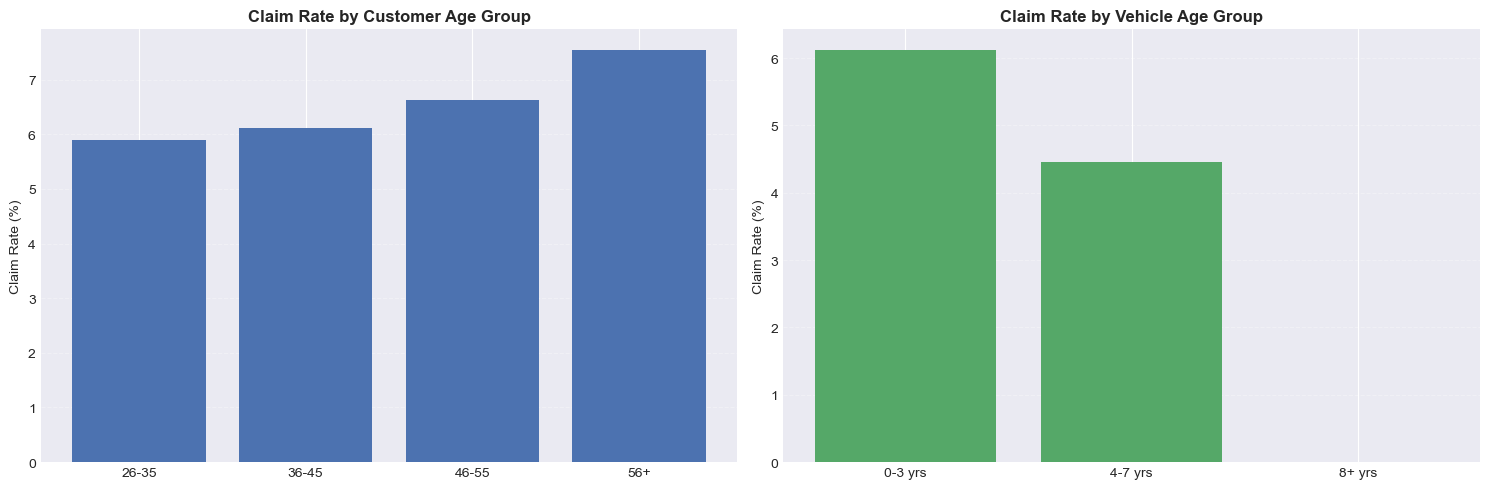

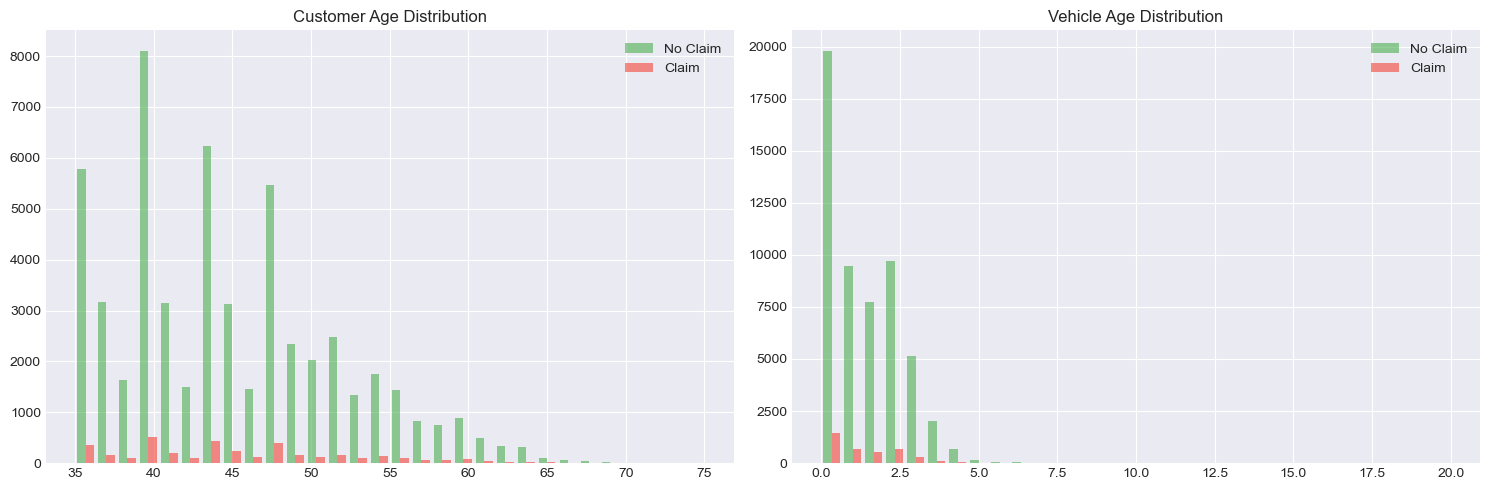

In [13]:
# -------------------------------
# 1. Summary statistics (clean view)
# -------------------------------
age_features = ['customer_age', 'vehicle_age']

for col in age_features:
    print(f"\n {col.replace('_', ' ').title()}")
    print(f"   Range  : {df[col].min()} - {df[col].max()}")
    print(f"   Mean   : {df[col].mean():.2f}")
    print(f"   Median : {df[col].median():.2f}")

# -------------------------------
# 2. Create bins (standardized approach)
# -------------------------------
df['customer_age_bin'] = pd.cut(
    df['customer_age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

df['vehicle_age_bin'] = pd.cut(
    df['vehicle_age'],
    bins=[0, 3, 7, 100],
    labels=['0-3 yrs', '4-7 yrs', '8+ yrs']
)

# -------------------------------
# 3. Claim rate function (reusable)
# -------------------------------
def claim_rate_by_group(feature):
    return (df.groupby(feature)['claim_status'].mean() * 100).sort_index()

# -------------------------------
# 4. Age group analysis table
# -------------------------------
age_results = pd.DataFrame({
    "customer_age_claim_rate": claim_rate_by_group('customer_age_bin'),
    "vehicle_age_claim_rate": claim_rate_by_group('vehicle_age_bin')
})

display(age_results)

# -------------------------------
# 5. Visualization (clean + comparative)
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Customer age
customer_rates = claim_rate_by_group('customer_age_bin')
axes[0].bar(customer_rates.index, customer_rates.values, color="#4C72B0")
axes[0].set_title("Claim Rate by Customer Age Group", fontweight='bold')
axes[0].set_ylabel("Claim Rate (%)")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Vehicle age
vehicle_rates = claim_rate_by_group('vehicle_age_bin')
axes[1].bar(vehicle_rates.index, vehicle_rates.values, color="#55A868")
axes[1].set_title("Claim Rate by Vehicle Age Group", fontweight='bold')
axes[1].set_ylabel("Claim Rate (%)")
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------
# 6. Distribution comparison (clean overlay histograms)
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Customer age distribution
axes[0].hist(
    [df[df['claim_status'] == 0]['customer_age'],
     df[df['claim_status'] == 1]['customer_age']],
    bins=30,
    label=['No Claim', 'Claim'],
    alpha=0.6,
    color=['#4CAF50', '#F44336']
)

axes[0].set_title("Customer Age Distribution")
axes[0].legend()

# Vehicle age distribution
axes[1].hist(
    [df[df['claim_status'] == 0]['vehicle_age'],
     df[df['claim_status'] == 1]['vehicle_age']],
    bins=30,
    label=['No Claim', 'Claim'],
    alpha=0.6,
    color=['#4CAF50', '#F44336']
)

axes[1].set_title("Vehicle Age Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

Customer ages range from 35 to 75 with an average of 44.8 years, showing a mostly mature customer base, while vehicle ages are generally low with a mean of 1.39 years, indicating newer insured vehicles dominate the portfolio. When grouped, claim rates gradually increase with customer age, peaking in the 56+ category, suggesting older clients slightly contribute more to claims. Vehicle age shows a weaker and less consistent pattern, though mid-aged vehicles (4–7 years) show noticeable variation compared to newer ones. Overall, customer age appears to have a more stable relationship with claim behaviour than vehicle age. These patterns suggest age-related factors may play a supporting but not dominant role in predicting claims.

### Multivariate Interaction Analysis

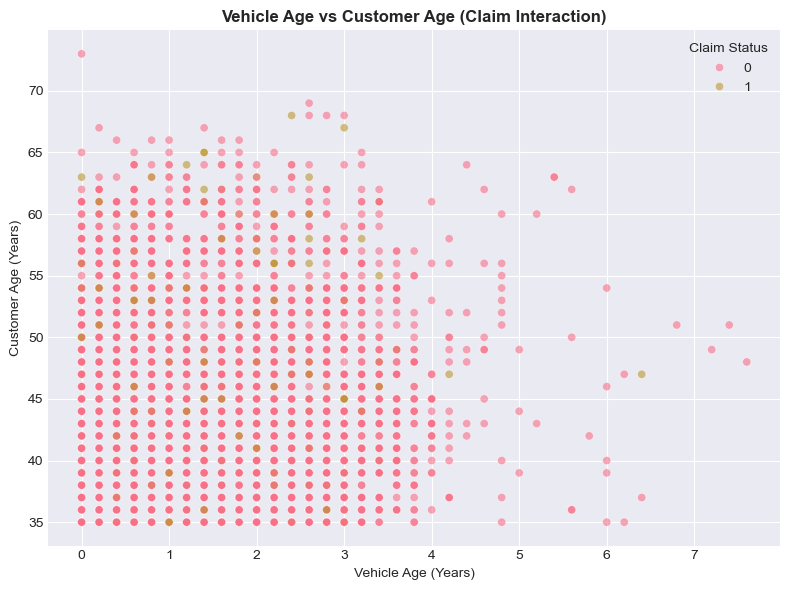

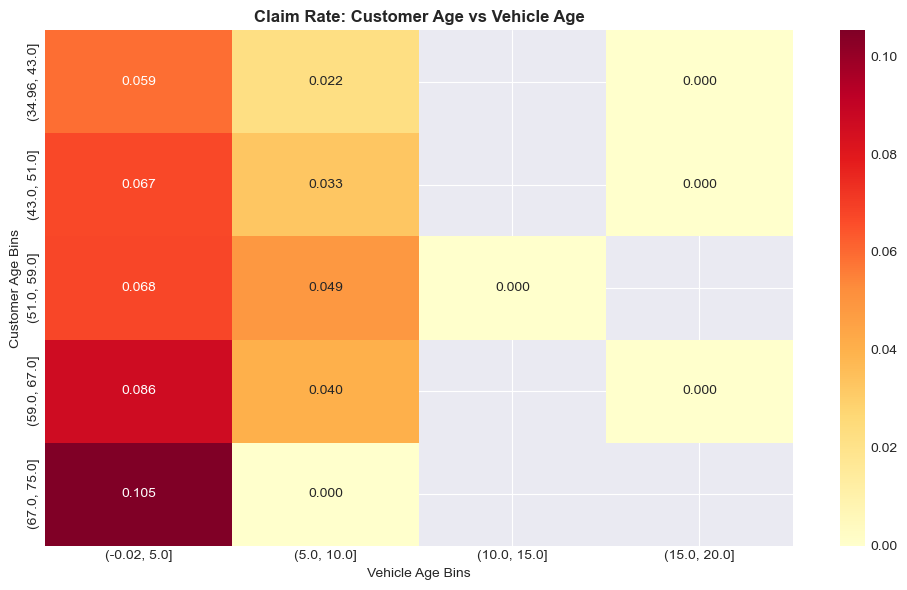

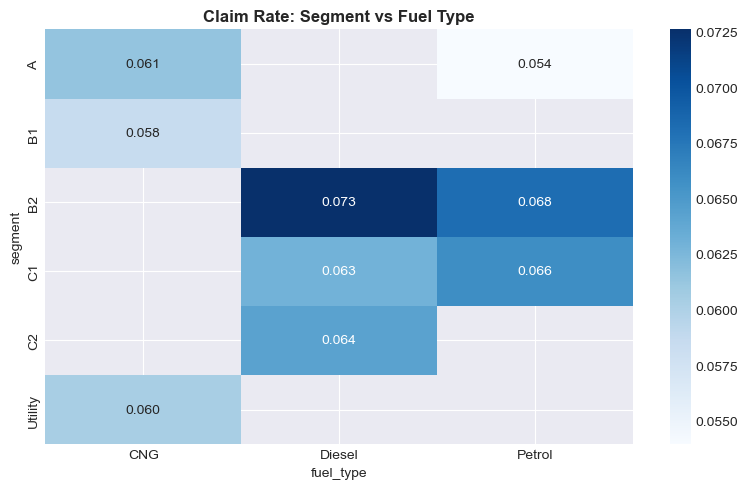

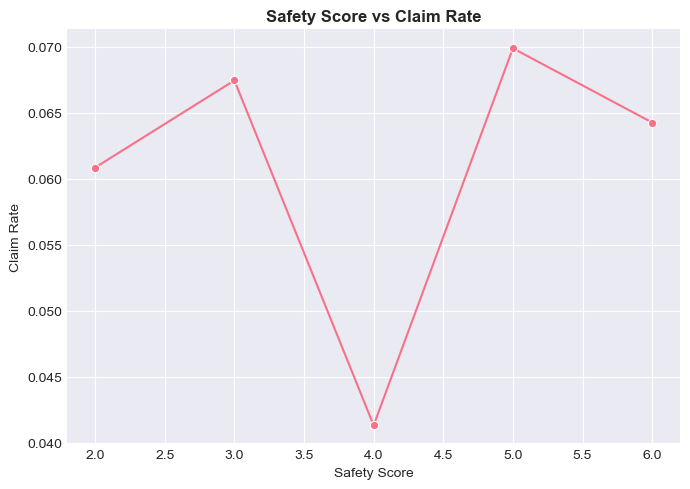

In [14]:
# -------------------------------------------------
# 1. Vehicle Age vs Customer Age (Risk Interaction)
# -------------------------------------------------
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='vehicle_age',
    y='customer_age',
    hue='claim_status',
    alpha=0.6
)

plt.title("Vehicle Age vs Customer Age (Claim Interaction)", fontweight='bold')
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Customer Age (Years)")
plt.legend(title="Claim Status")
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 2. Average Claim Rate: Vehicle Age × Customer Age Bins
# -------------------------------------------------

age_pivot = df.pivot_table(
    values='claim_status',
    index=pd.cut(df['customer_age'], bins=5),
    columns=pd.cut(df['vehicle_age'], bins=4),
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(age_pivot, annot=True, fmt=".3f", cmap="YlOrRd")

plt.title("Claim Rate: Customer Age vs Vehicle Age", fontweight='bold')
plt.xlabel("Vehicle Age Bins")
plt.ylabel("Customer Age Bins")
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 3. Segment vs Fuel Type Interaction
# -------------------------------------------------

segment_fuel = df.pivot_table(
    values='claim_status',
    index='segment',
    columns='fuel_type',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(segment_fuel, annot=True, fmt=".3f", cmap="Blues")

plt.title("Claim Rate: Segment vs Fuel Type", fontweight='bold')
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 4. Safety Score vs Claim Rate
# -------------------------------------------------

safety_features = [
    'is_esc', 'is_brake_assist', 'is_parking_sensors',
    'is_parking_camera', 'is_tpms', 'is_speed_alert'
]

df['safety_score'] = df[safety_features].sum(axis=1)

safety_claim = df.groupby('safety_score')['claim_status'].mean()

plt.figure(figsize=(7, 5))
sns.lineplot(x=safety_claim.index, y=safety_claim.values, marker='o')

plt.title("Safety Score vs Claim Rate", fontweight='bold')
plt.xlabel("Safety Score")
plt.ylabel("Claim Rate")
plt.tight_layout()
plt.show()

The exploratory data analysis provides a clear understanding of the insurance dataset structure, data quality, and key risk drivers behind claims. We observe a low overall claim rate (~6.4%), indicating a highly imbalanced target with relatively rare claim events. Numerical and categorical analyses show that most individual features have weak standalone relationships with claims, but certain variables like subscription length, customer age, region, and selected safety features show measurable influence. Safety and vehicle characteristics introduce subtle but consistent differences in claim behaviour, while categorical segmentation (region, segment, fuel type) highlights pockets of higher risk variation. Overall, the EDA reveals that claim prediction is driven more by feature interactions and combined effects rather than any single dominant variable, setting a strong foundation for feature engineering and modelling.
